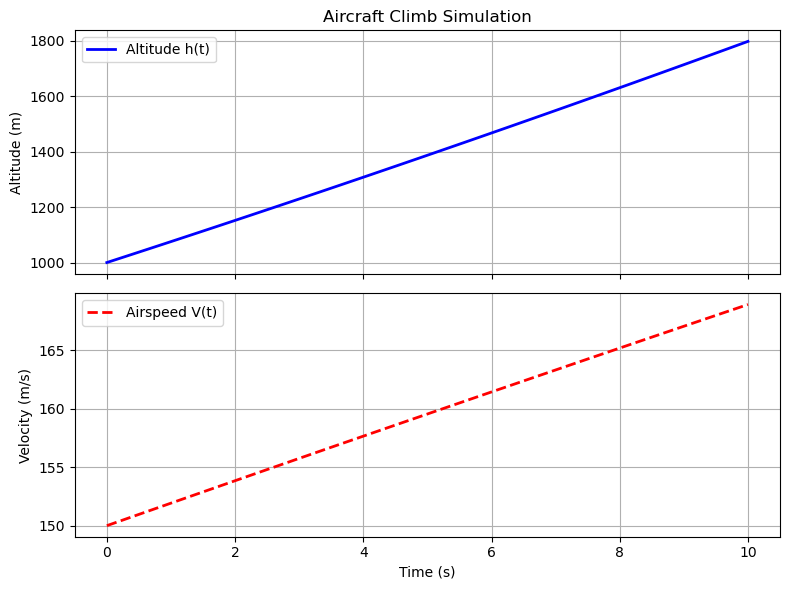

In [ ]:
#now on to simulation of the climb rate. we can use the same model as before,
# but now we will be looking at the rate of climb instead of the maximum speed.
"the idea now is to apply newton's equation to form an ODE with V = dh/dt we then have m(dV/dt) = Thrust - Drag - mg sin(theta), dh/dt  = V sin(theta) "
"then integrate them with scipy buildin functions"

import math
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
theta = math.pi / 6      # climb angle (30 deg)
thro = 0.5               
T_0 = 147500             
rho_0 = 1.225            
lc = 0.5                 
Temp_0 = 288.15          # sea level temperature (K)
g = 9.81
L = -0.0065
R = 8.3144621
M = 0.0289

m = 10000                # kg
wing_area = 10.0         # m^2
dc_0 = 0.02
k = 0.1
dc = k * lc**2 + dc_0    # 0.045

# ODE: y1 = altitude, y2 = velocity
def ode_function(t, y):
    y1, y2 = y
    dy1dt = y2 * math.sin(theta)
    
    # Air density at altitude y1
    rho = rho_0 * (1 - L * y1 / Temp_0) ** (g * M / (R * L) - 1)
    drag = 0.5 * rho * (y2**2) * wing_area * dc
    thrust = T_0 * thro
    
    dy2dt = (thrust - drag - m * g * math.sin(theta)) / m
    return [dy1dt, dy2dt]

# boundary conditions: 1000 m altitude, 150 m/s speed
y0 = [1000, 150]
t_span = (0, 10)

sol = solve_ivp(ode_function, t_span, y0, method='RK45', dense_output=True)

t_eval = np.linspace(t_span[0], t_span[1], 100)
y_eval = sol.sol(t_eval)

altitude = y_eval[0]
velocity = y_eval[1]

# Plot with two subplots so both curves are clearly visible
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(t_eval, altitude, 'b', linewidth=2, label='Altitude h(t)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('Aircraft Climb Simulation')
ax1.grid(True)
ax1.legend()

ax2.plot(t_eval, velocity, 'r--', linewidth=2, label='Airspeed V(t)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


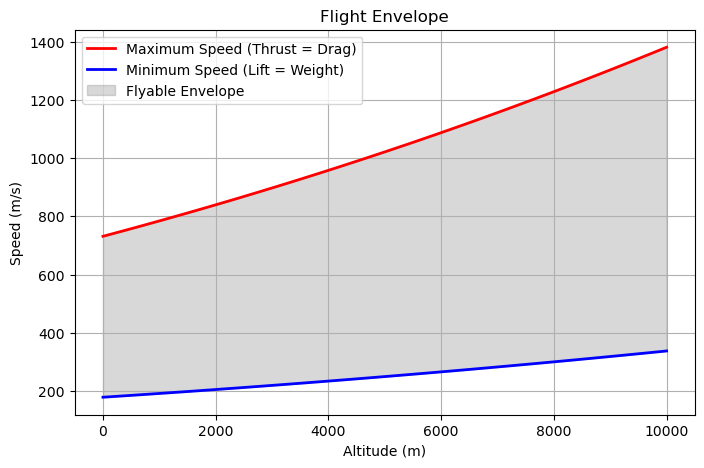

In [ ]:
"calculation of the maximum and minimum achievable speed on different altitudes, "
"the maximum speed is achieved when the drag is equal to the thrust, "
"and the minimum speed is achieved when the lift is equal to the weight of the airplane."
"i.e V_max = sqrt((2 * T_0 * thro) / (rho * wing_area * dc)) because "
"T = D, and V_min = sqrt((2 * m * g) / (rho * wing_area * lc)) because L = W"

# flight envelope calculation:
# V_max from T = D (at 100% full thrust T_0)
# V_min from L = W (stall limit at lc)

def max_speed(h):
    rho = rho_0 * (1 - L * h / Temp_0) ** (g * M / (R * L) - 1)
    V_max = math.sqrt((2 * T_0 * 1.0) / (rho * wing_area * dc))  # full throttle for V_max
    return V_max

def min_speed(h):
    rho = rho_0 * (1 - L * h / Temp_0) ** (g * M / (R * L) - 1)
    V_min = math.sqrt((2 * m * g) / (rho * wing_area * lc))       # weight support for V_min
    return V_min


h_values = np.linspace(0, 10000, 100)
V_max_values = [max_speed(h) for h in h_values]
V_min_values = [min_speed(h) for h in h_values]

# plot the flight envelope
plt.figure(figsize=(8, 5))
plt.plot(h_values, V_max_values, label='Maximum Speed (Thrust = Drag)', color='r', linewidth=2)
plt.plot(h_values, V_min_values, label='Minimum Speed (Lift = Weight)', color='b', linewidth=2)
#for better visualization of the flight envelope
plt.fill_between(h_values, V_min_values, V_max_values, color='gray', alpha=0.3, label='Flyable Envelope')

plt.xlabel('Altitude (m)')
plt.ylabel('Speed (m/s)')
plt.title('Flight Envelope')
plt.legend()
plt.grid(True)
plt.show()

'''
some notable assumptions made in this simulation include: 
1. The climb angle is constant at 30 degrees.
2. The thrust is constant at 50% of the maximum thrust.
3. The drag and lift coefficients are constant(quasi steady) and do not change with speed or altitude.
'''

"""
This is a 1-DOF point-mass flight performance model simulating climb trajectory under Newton's second law, 
coupled with a barometric International Standard Atmosphere (ISA). 
The flight envelope identifies the flyable regime bounded by aerodynamic stall(L=W) and 
maximum available thrust equilibrium (T=D). Something notable about the realism of this model is that it does
not account for the effects of compressibility,and how thrust and drag vary with Mach number and altitude.
It only considers the effects of altitude on air density. There is also transort delay in the response of 
the aircraft to changes in thrust and drag, which is not captured in this model. And more importantly the trasonic
Mach limit is not considered, meaning that the aircraft may exceed the speed of sound without experiencing. Additionally,
the model does not account for the effects of wind, turbulence, and other environmental factors 
that can affect the climb performance of an aircraft.
"""

